# 3 — RESTORE per-image normalization

> ## ⚠️ RETIRED 2026-07-23 — the "Run" and "Post-run validation" sections below no longer execute
>
> The curated pair web (`config.MARKER_PAIRS` / `FUNCTIONAL_PAIRS`) and its drivers
> (`restore.run_restore` / `run_restore_functional`) are **deleted**, and the pipeline's `restore`
> stage now **raises** instead of running. Ten of those pairs used CD20 as the reference, and there
> is no mechanical substitute: CD3e is invalid for CD4/CD8/FOXP3 (which are CD3e+), and epithelium
> expresses PD-L1 and IDO1. Rather than maintain a second, known-wrong web until Gate 4 replaces
> production wiring, it was removed.
>
> The method described in the paragraph below (`mean + 3σ` on the reference-positive population,
> cohort-median guard, `{m}_pos / {m}_norm / {m}_log2r` under `data/restore_gated_redsea/`) is
> **superseded**. The manuscript-faithful method uses an **NNMF separator** and a divisor equal to
> the **MAXIMUM** target intensity among the accepted target-negative controls. Ground truth is
> `RESTORE.pdf` + `RESTOREsup.pdf`; the gate plan is `docs/restore_faithful_rebuild_plan.md`.
>
> **Gate 2 entry point instead:**
> ```
> python -m phenocycler.restore_validation evaluate-locked --help
> ```
> Nothing is accepted yet — no pair, no divisor, no normalized output. The next action is the human
> pair review in `data/restore_pair_validation/expanded_review_v9/review_decisions.csv`.
>
> **The diagnostics section below is still live** — it reads `data/cells_redsea/` and uses the kept
> machinery (`idx_select`, `neg_stat`, `fit_clusters`), which the new method reuses.

Fits KMeans/GMM/**SSC** per image on a biologically-curated web of directional, mutually-exclusive marker
pairs (`config.MARKER_PAIRS`); each `[target ← reference]` thresholds the target against the
reference-positive (therefore target-negative) population at `mean + 3σ`, guards degenerate per-image
thresholds against the cohort median, and writes `{m}_pos / {m}_norm / {m}_log2r` to
`data/restore_gated_redsea/`. Runs on the REDSEA-corrected cells — do **not** log-transform first.

**Begin with the threshold-tracing diagnostics** — trace the per-image threshold one transformation at a
time, validated against each donor's OWN within-islet valley (a summary metric once falsely flagged INS, a
clean marker, as the worst pair) — then run RESTORE.

In [3]:
# Parameters for this step (self-contained -- no config.ini). Edit the paths for your machine.
%load_ext autoreload
# pick up edits to the phenocycler package without a kernel restart
%autoreload 2                                         
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))   # make `phenocycler` importable from notebooks/
from phenocycler import PipelineConfig

REPO = pathlib.Path.cwd().resolve().parents[1]        # Islet-Explorer-Senior (parent of the submodule; data/ lives here)

# Run on a subset of donors (None = every donor under data/cells/donor_id=*).
DONORS = ["6374"]            # e.g. ["6374", "6380"] to iterate on a few

# Threshold-tracing diagnostics (below): trace ONE marker pair on a chosen donor.
MARKER_PAIR    = ["INS", "GCG"]   # [target, reference]; RESTORE thresholds the TARGET
THRESHOLD_STAT = "mean3sd"        # mean3sd (pipeline) | mad | pctile | logmad
MODEL          = "SSC"            # SSC (default) | GMM | KMeans
IDX_FLOOR_Q    = 0.5              # idx_select OFF-marker near-zero quantile (<=0 -> vendored co-positive >50)
SUBSAMPLE      = 15000
SEED           = 0

cfg = PipelineConfig(
    data_dir       = REPO / "data",
    donor_metadata = pathlib.Path("/home/smith6jt/IO60panc2nd/donor_metadata_panc.xlsx"),   # disease-status for the cross-donor diagnostic + validation
    # --- RESTORE parameters (this step) ---
    restore_model         = "SSC",
    restore_subsample     = 15000,
    restore_robust        = True,
    restore_robust_factor = 3.0,
    restore_min_cell_area = 5.0,
    restore_seed          = 0,
    restore_idx_floor_q   = 0.5,
    n_jobs = 8,
)
donors = DONORS or cfg.discover_donors()
print(f"donors: {len(donors)} " + ("(subset)" if DONORS else "(all)") + f" -> {donors[:6]}" + (" ..." if len(donors) > 6 else ""))

donors: 1 (subset) -> ['6374']


## Diagnostics — RESTORE threshold tracing (begin here)

Traces `data/cells_redsea/` (RESTORE's INPUT — available before RESTORE runs), so you can inspect the
threshold on a chosen donor/pair, then run RESTORE below. Change `MARKER_PAIR` / `THRESHOLD_STAT` / `MODEL`
/ `IDX_FLOOR_Q` in the Parameters cell and re-run.

In [5]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from phenocycler.diagnostics import read_donor, r_otsu, idx_select, neg_stat, fit_clusters, status_map
from phenocycler.config import STATUS_ORDER
# AFTER the imports: phenocycler.restore sets a non-interactive backend on import
%matplotlib inline               

L = lambda a: np.log10(np.clip(np.asarray(a, float), 0, None) + 1)
DIAG_DONOR = donors[0]          # trace this donor; any id in `donors`
TGT, REF = MARKER_PAIR
print(f"tracing donor {DIAG_DONOR} ({status_map(cfg).get(DIAG_DONOR,'?')})  pair {MARKER_PAIR}  "
      f"stat={THRESHOLD_STAT} model={MODEL} idx_floor_q={IDX_FLOOR_Q}")

tracing donor 6374 (ND)  pair ['INS', 'GCG']  stat=mean3sd model=SSC idx_floor_q=0.5


### Steps 0–1 — load + raw distributions (within-islet Otsu valley)

`log10(MFI+1)` of target/reference, whole tissue vs within-islet (core). The within-islet Otsu valley (dashed) is the honest background↔signal boundary; the whole-tissue Otsu (dotted) collapses into background for a rare marker like INS — the artifact that misled the summary metric.

6374: 2,533,143 cells | core(islet)=58,734


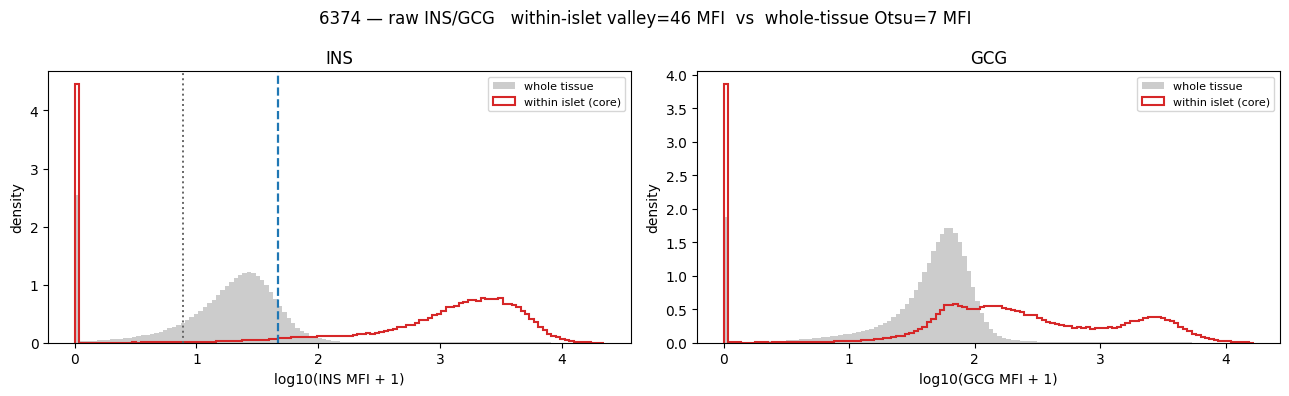

In [6]:
df = read_donor(cfg, DIAG_DONOR, MARKER_PAIR)
T = df[TGT].to_numpy(float); R = df[REF].to_numpy(float)
core = df.cell_region.eq("core").to_numpy()
print(f"{DIAG_DONOR}: {len(df):,} cells | core(islet)={core.sum():,}")
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for a, (name, x) in zip(ax, [(TGT, T), (REF, R)]):
    a.hist(L(x), bins=120, color="0.8", label="whole tissue", density=True)
    a.hist(L(x[core]), bins=120, histtype="step", color="C3", lw=1.5, label="within islet (core)", density=True)
    a.set_xlabel(f"log10({name} MFI + 1)"); a.set_ylabel("density"); a.legend(fontsize=8); a.set_title(name)
v_islet = r_otsu(L(T[core])); v_all = r_otsu(L(T))
ax[0].axvline(v_islet, ls="--", color="C0", lw=1.6); ax[0].axvline(v_all, ls=":", color="0.4", lw=1.4)
fig.suptitle(f"{DIAG_DONOR} — raw {TGT}/{REF}   within-islet valley={10**v_islet-1:.0f} MFI  "
             f"vs  whole-tissue Otsu={10**v_all-1:.0f} MFI")
fig.tight_layout(); plt.show()

### Step 2 — idx_select co-expression prefilter

RESTORE clusters only cells passing `idx_select`. Left = floor **off** (vendored `>50`), right = floor **on** (per-marker quantile `IDX_FLOOR_Q`, the corrected mutually-exclusive single-positive arms).

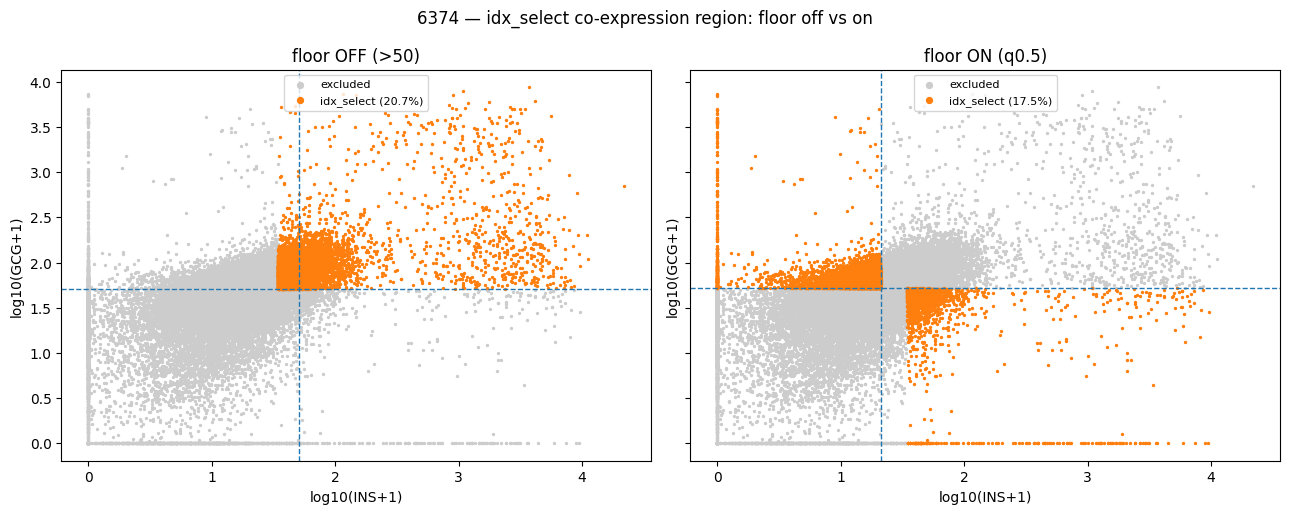

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5.2), sharex=True, sharey=True)
rng = np.random.default_rng(SEED); pi = rng.choice(len(T), min(40000, len(T)), replace=False)
for a, fq in zip(ax, [0.0, IDX_FLOOR_Q if IDX_FLOOR_Q > 0 else 0.5]):
    sel, f0, f1 = idx_select(T, R, fq)
    a.scatter(L(T[pi][~sel[pi]]), L(R[pi][~sel[pi]]), s=2, c="0.8", label="excluded")
    a.scatter(L(T[pi][ sel[pi]]), L(R[pi][ sel[pi]]), s=2, c="C1", label=f"idx_select ({100*sel.mean():.1f}%)")
    a.axvline(np.log10(f0+1), ls="--", c="C0", lw=1); a.axhline(np.log10(f1+1), ls="--", c="C0", lw=1)
    a.set_xlabel(f"log10({TGT}+1)"); a.set_ylabel(f"log10({REF}+1)"); a.legend(fontsize=8, markerscale=3)
    a.set_title(f"floor {'OFF (>50)' if fq==0 else f'ON (q{fq})'}")
fig.suptitle(f"{DIAG_DONOR} — idx_select co-expression region: floor off vs on"); fig.tight_layout(); plt.show()

### Step 3 — 2-cluster split → the NEGATIVE population

The negative cluster = max spread on the reference axis (reference-positive ⇒ target-negative). The table compares all three models — KMeans/GMM often grab a tiny/degenerate negative cluster (absurd thresholds) while **SSC** picks the broad background (why the pipeline uses SSC; SSC is stochastic + slow).

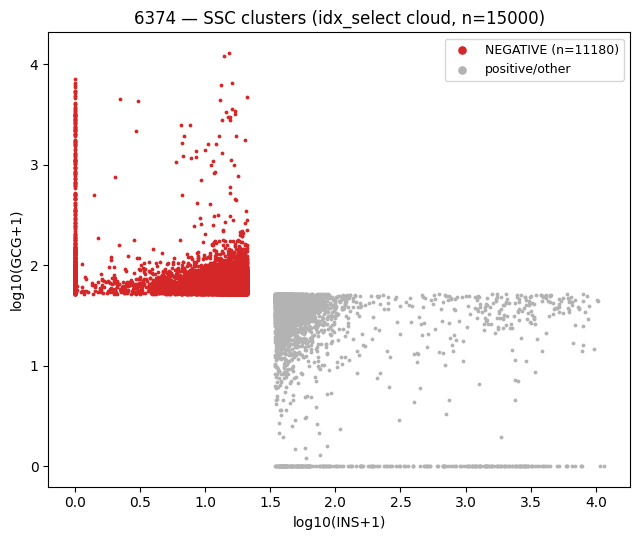

threshold (raw MFI) by model x statistic — SSC gives the broad negative cluster:


,neg_n,mean3sd,mad,pctile,logmad
model,,,,,
KMeans,14854,474.0,37.0,1943.0,68.0
GMM,11180,29.0,30.0,20.0,40.0
SSC,11180,29.0,30.0,20.0,40.0


In [8]:
sel, f0, f1 = idx_select(T, R, IDX_FLOOR_Q)
cloud0 = np.column_stack([T[sel], R[sel]])
cloud, labels, neg = fit_clusters(cloud0, MODEL, subsample=SUBSAMPLE, seed=SEED)
negv = cloud[labels == neg][:, 0]
fig, a = plt.subplots(figsize=(6.5, 5.5))
for lab in (0, 1):
    c = cloud[labels == lab]
    a.scatter(L(c[:, 0]), L(c[:, 1]), s=3, c=("C3" if lab == neg else "0.7"),
              label=(f"NEGATIVE (n={len(c)})" if lab == neg else "positive/other"))
a.set_xlabel(f"log10({TGT}+1)"); a.set_ylabel(f"log10({REF}+1)"); a.legend(fontsize=9, markerscale=3)
a.set_title(f"{DIAG_DONOR} — {MODEL} clusters (idx_select cloud, n={len(cloud)})"); fig.tight_layout(); plt.show()
rows = []
for mdl in ("KMeans", "GMM", "SSC"):
    try:
        cl, lb, ng = fit_clusters(cloud0, mdl, subsample=SUBSAMPLE, seed=SEED)
        nv = cl[lb == ng][:, 0]
        rows.append({"model": mdl, "neg_n": len(nv), "mean3sd": neg_stat(nv, "mean3sd"),
                     "mad": neg_stat(nv, "mad"), "pctile": neg_stat(nv, "pctile"), "logmad": neg_stat(nv, "logmad")})
    except Exception as e:
        rows.append({"model": mdl, "neg_n": f"ERR {e}"})
print("threshold (raw MFI) by model x statistic — SSC gives the broad negative cluster:")
display(pd.DataFrame(rows).set_index("model").round(0))

### Steps 4–5 — threshold statistic + apply/validate

Left: the negative cluster's target values with the four candidate cutoffs (`mean+3σ` is pulled up by the right skew; `mad`/`logmad` resist it). Right: the **chosen** `THRESHOLD_STAT` applied to all cells — does the cut sit at the within-islet valley and give a biologically-sane `%⁺`?

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
ax[0].hist(L(negv), bins=100, color="0.8", density=True)
for s, c in {"mean3sd": "C3", "mad": "C0", "pctile": "C2", "logmad": "C4"}.items():
    thr_s = neg_stat(negv, s)
    ax[0].axvline(np.log10(thr_s + 1), color=c, lw=1.8, label=f"{s} = {thr_s:.0f} ({100*(T>=thr_s).mean():.2f}%+)")
ax[0].axvline(r_otsu(L(T[core])), ls="--", color="k", lw=1.2, label="within-islet valley")
ax[0].set_xlabel(f"log10({TGT}+1)  — NEGATIVE cluster"); ax[0].set_ylabel("density"); ax[0].legend(fontsize=8)
ax[0].set_title("threshold statistic on the negative population")
thr = neg_stat(negv, THRESHOLD_STAT)
ax[1].hist(L(T), bins=140, color="0.8", density=True, label="all cells")
ax[1].hist(L(T[core]), bins=140, histtype="step", color="C3", lw=1.3, density=True, label="within islet")
ax[1].axvline(np.log10(thr + 1), color="C1", lw=2.2, label=f"{THRESHOLD_STAT} = {thr:.0f} MFI")
ax[1].axvline(r_otsu(L(T[core])), ls="--", color="k", lw=1.4, label="within-islet valley")
ax[1].set_xlabel(f"log10({TGT}+1)"); ax[1].legend(fontsize=8)
ax[1].set_title(f"applied {TGT} threshold -> {100*(T>=thr).mean():.2f}% positive")
fig.suptitle(f"{DIAG_DONOR} — {TGT} threshold on the negative population + applied"); fig.tight_layout(); plt.show()
print(f"{TGT} threshold={thr:.0f} MFI -> {100*(T>=thr).mean():.2f}% of all cells "
      f"({100*(T[core]>=thr).mean():.1f}% within islet). within-islet valley={10**r_otsu(L(T[core]))-1:.0f} MFI.")

### Step 6 — cross-donor disease gradient + robust guard

The chosen (floor, statistic, model) over the (subset of) donors: **% target-positive by disease status** (raw hatched vs cohort-median-guarded solid). For INS this must fall ND → Aab+ → T1D. The guard imputes any per-donor threshold >3× or <⅓× the cohort median (`build_chosen_lut`). SSC × N donors ≈ 1–2 min — the `DONORS` subset keeps it fast.

In [ ]:
smap = status_map(cfg)
rows = []
for d in donors:                                   # `donors` respects the DONORS subset
    dd = read_donor(cfg, d, MARKER_PAIR)
    Td = dd[TGT].to_numpy(float); Rd = dd[REF].to_numpy(float)
    sel_d, _, _ = idx_select(Td, Rd, IDX_FLOOR_Q)
    cl, lb, ng = fit_clusters(np.column_stack([Td[sel_d], Rd[sel_d]]), MODEL, subsample=SUBSAMPLE, seed=SEED)
    rows.append({"donor": d, "status": smap.get(d, "?"), "thr_raw": neg_stat(cl[lb == ng][:, 0], THRESHOLD_STAT), "_T": Td})
res = pd.DataFrame(rows)
FAC = cfg.restore_robust_factor; med = np.nanmedian(res.thr_raw)
res["thr_guard"] = res.thr_raw.apply(lambda t: med if (not np.isfinite(t) or t <= 0 or t > FAC*med or t < med/FAC) else t)
res["pct_raw"]   = [100*(r._T >= r.thr_raw).mean()   for _, r in res.iterrows()]
res["pct_guard"] = [100*(r._T >= r.thr_guard).mean() for _, r in res.iterrows()]
order = res.status.map({s: i for i, s in enumerate(STATUS_ORDER)}).fillna(9)
res = res.drop(columns="_T").assign(_o=order).sort_values("_o").drop(columns="_o")
cc = res.status.map({"ND": "#4477AA", "AAB": "#CC6633", "T1D": "#228833"}).fillna("0.6").tolist()
fig, ax = plt.subplots(1, 2, figsize=(13, 4)); xs = np.arange(len(res))
ax[0].bar(xs, res.pct_raw, color=cc, alpha=0.35, hatch="//", label="raw")
ax[0].bar(xs, res.pct_guard, color=cc, label="guarded")
ax[0].set_xticks(xs); ax[0].set_xticklabels(res.donor); ax[0].set_ylabel(f"% {TGT} positive")
ax[0].set_title(f"{TGT}+ by donor (floor {IDX_FLOOR_Q}, {THRESHOLD_STAT}, {MODEL})"); ax[0].legend(fontsize=8)
for x, (_, r) in zip(xs, res.iterrows()): ax[0].text(x, max(r.pct_raw, r.pct_guard), r.status, ha="center", va="bottom", fontsize=8)
ax[1].bar(xs, res.thr_raw, color=cc, alpha=0.35, hatch="//"); ax[1].bar(xs, res.thr_guard, color=cc)
ax[1].axhline(med, ls=":", c="k", lw=1, label=f"cohort median {med:.0f}"); ax[1].set_xticks(xs); ax[1].set_xticklabels(res.donor)
ax[1].set_ylabel("threshold (raw MFI)"); ax[1].set_title("per-donor threshold: raw vs guarded"); ax[1].legend(fontsize=8)
fig.tight_layout(); plt.show()
display(res.round(1).set_index("donor"))
for lab in ("pct_raw", "pct_guard"):
    byst = res.groupby("status")[lab].mean().reindex([s for s in STATUS_ORDER if s in set(res.status)])
    print(f"mean %+ by status [{lab:9}]:", {k: round(v, 2) for k, v in byst.items()})

## Run — RESTORE on the (subset of) donors

Fits + applies over `DONORS` (both threshold fitting and per-cell apply honor the subset). Requires the
vendored RESTORE submodule (`external/RESTORE`) and `spams` for SSC (`pip install spams-bin`).

In [ ]:
# RETIRED 2026-07-23 — `run_restore` is deleted along with the curated pair web it consumed
# (MARKER_PAIRS / FUNCTIONAL_PAIRS; ten of those pairs referenced CD20, which is too sparse in
# pancreas to define a negative control). The pipeline's `restore` stage raises for the same reason.
#
#   was:  from phenocycler.restore import run_restore
#         run_restore(cfg, donors=DONORS, n_jobs=cfg.n_jobs)
#
# Gate 2 replacement — screen candidate pairs, emit NO divisor and NO positivity call:
#   python -m phenocycler.restore_validation evaluate-locked --help
# See docs/restore_faithful_rebuild_plan.md. Nothing is accepted yet, so the two validation cells
# below (which read cfg.restore_thresholds_csv / positive_fractions.csv / restore_gated_dir) have
# no input and will report the missing files.
#
# Still available from phenocycler.restore: the proliferation pass (Ki67/PCNA bimodal binarization),
# which does not use the retired pair web:
#   python -m phenocycler.restore --proliferation
raise NotImplementedError(
    "run_restore was retired 2026-07-23 with MARKER_PAIRS/FUNCTIONAL_PAIRS; "
    "use `python -m phenocycler.restore_validation evaluate-locked` (Gate 2)."
)

In [ ]:
import pandas as pd
thr = pd.read_csv(cfg.restore_thresholds_csv)
thr[thr.chosen].pivot(index='marker', columns='image', values='threshold').round(1)

## Post-run validation

RESTORE-derived per-image positive fractions recover both T1D hallmarks: **β-cell INS⁺ falls** and
**T-cell CD3e⁺ rises** ND → Aab+ → T1D. (a) mean % positive per marker across images; (b) the disease-status
trend, computed from each donor's own RESTORE `_pos` calls.

In [ ]:
# (a) RESTORE positive fractions -> mean % positive per marker across images.
import pandas as pd
pf = cfg.restore_dir / "positive_fractions.csv"
if pf.exists():
    frac = pd.read_csv(pf)
    mcol = "marker" if "marker" in frac.columns else frac.columns[1]
    fcol = "frac_pos" if "frac_pos" in frac.columns else next(c for c in frac.columns if "frac" in c.lower())
    print(f"RESTORE positive fractions ({pf.name}):")
    display((100 * frac.groupby(mcol)[fcol].mean()).round(2).sort_values(ascending=False)
            .to_frame("mean % positive across images"))
else:
    print(f"{pf} not found — run the restore cell above.")

In [ ]:
# (b) Biological hallmark recovery: beta-cell (INS+) loss + T-cell (CD3e+) gain ND -> Aab+ -> T1D.
import pandas as pd
import pyarrow.dataset as ds
from phenocycler.lineage import status_map
from phenocycler.config import STATUS_ORDER

smap = status_map(cfg)
if smap:
    rows = []
    for d in donors:
        t = ds.dataset(cfg.restore_gated_dir / f"donor_id={d}", format="parquet").to_table(
                columns=["INS_pos", "CD3e_pos"]).to_pandas()
        rows.append({"status": smap.get(d, "?"),
                     "INS+ %": 100 * t["INS_pos"].mean(), "CD3e+ %": 100 * t["CD3e_pos"].mean()})
    trend = pd.DataFrame(rows).groupby("status")[["INS+ %", "CD3e+ %"]].mean().round(2)
    order = [s for s in STATUS_ORDER if s in trend.index] + [s for s in trend.index if s not in STATUS_ORDER]
    print("Hallmark recovery (mean % positive by disease status):")
    display(trend.reindex(order))
else:
    print("donor metadata unreadable — skipping the disease-trend recompute.")